In [8]:
import os
import pandas as pd
import numpy as np

# Configuration de l'affichage Pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 1000)

csv_path = "resultats_deadlift_benchmark.csv"

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    print(f"✅ {len(df)} lignes chargées depuis '{csv_path}'")
    display(df.head())
else:
    print(f"❌ Fichier '{csv_path}' introuvable dans le répertoire courant.")

✅ 21 lignes chargées depuis 'resultats_deadlift_benchmark.csv'


,Fichier,Modèle,Essai,Mouvement,Score_Global_3,Max_Global_3,Persona,Persona_Justification,starting_position_note_4,starting_position_note_3,starting_position_explanation,slack_pull_and_lat_engagement_note_4,slack_pull_and_lat_engagement_note_3,slack_pull_and_lat_engagement_explanation,leg_drive_activation_note_4,leg_drive_activation_note_3,leg_drive_activation_explanation,hip_hinge_mechanics_note_4,hip_hinge_mechanics_note_3,hip_hinge_mechanics_explanation,core_bracing_and_spine_neutrality_note_4,core_bracing_and_spine_neutrality_note_3,core_bracing_and_spine_neutrality_explanation,bar_path_and_proximity_note_4,bar_path_and_proximity_note_3,bar_path_and_proximity_explanation,lockout_execution_note_4,lockout_execution_note_3,lockout_execution_explanation,eccentric_control_and_descent_note_4,eccentric_control_and_descent_note_3,eccentric_control_and_descent_explanation
0,erwan_mauvais_slack.mp4,gemini-3.5-flash,1,Conventional deadlift,14,24,The Technician,"Demonstrates highly consistent, clean mechanics with minimal deviations across reps.",3,2,NaN,2,1,NaN,3,2,NaN,3,2,NaN,3,2,NaN,3,2,NaN,3,2,NaN,2,1,NaN
1,erwan_mauvais_slack.mp4,gemini-3.5-flash,2,Conventional deadlift,14,24,The Technician,"Demonstrates highly consistent, clean mechanics with minimal deviations across reps.",3,2,NaN,2,1,NaN,3,2,NaN,3,2,NaN,3,2,NaN,3,2,NaN,3,2,NaN,2,1,NaN
2,erwan_mauvais_slack.mp4,gemini-3.6-flash,1,Conventional deadlift,16,24,The Technician,"Demonstrates consistent, disciplined technique and balanced bar path throughout.",3,2,NaN,3,2,NaN,3,2,NaN,3,2,NaN,3,2,NaN,3,2,NaN,3,2,NaN,3,2,NaN
3,erwan_mauvais_slack.mp4,gemini-3.6-flash,2,Conventional deadlift,16,24,The Technician,"Maintains consistent, efficient mechanics across each repetition.",3,2,NaN,3,2,NaN,3,2,NaN,3,2,NaN,3,2,NaN,3,2,NaN,3,2,NaN,3,2,NaN
4,erwan_mauvais_slack.mp4,gemini-3.7-flash,2,Conventional deadlift,16,24,The Technician,"Consistent setup, clean bar path, and disciplined mechanics across every rep.",3,2,NaN,3,2,NaN,3,2,NaN,3,2,NaN,3,2,NaN,3,2,NaN,3,2,NaN,3,2,NaN


In [2]:
# Sélection des colonnes principales de résumé
cols_resume = ["Fichier", "Modèle", "Essai", "Score_Global_3", "Max_Global_3", "Persona", "Persona_Justification"]
cols_presentes = [col for col in cols_resume if col in df.columns]

# Affichage avec style
df[cols_presentes].style.set_properties(**{'text-align': 'left'}).set_table_styles([
    dict(selector='th', props=[('background-color', '#2c3e50'), ('color', 'white'), ('font-weight', 'bold')])
])

,Fichier,Modèle,Essai,Score_Global_3,Max_Global_3,Persona,Persona_Justification
0,video.mp4,gemini-3.5-flash,1,14,24,The Technician,"Your lifts display highly consistent mechanics, controlled descents, and excellent spinal neutrality across all repetitions."
1,video.mp4,gemini-3.5-flash,2,14,24,The Technician,"Your lifts display highly consistent mechanics, controlled descents, and excellent spinal neutrality across all repetitions."


In [4]:
# Récupération automatique de toutes les colonnes de notes sur 4
cols_notes_4 = [col for col in df.columns if col.endswith("_note_4")]

# Remplacement des "NA" textuels par NaN pour le calcul et le formatage visuel
df_scores_4 = df[["Fichier", "Modèle", "Essai"] + cols_notes_4].copy()

for col in cols_notes_4:
    df_scores_4[col] = pd.to_numeric(df_scores_4[col], errors='coerce')

# Renommage des colonnes pour un affichage plus lisible
noms_propres = {col: col.replace("_note_4", "").replace("_", " ").title() for col in cols_notes_4}
df_scores_4_pretty = df_scores_4.rename(columns=noms_propres)

# Affichage coloré (vert = 4/4, rouge = 1/4, gris = NA)
crit_renommes = list(noms_propres.values())
(
    df_scores_4_pretty.style
    .background_gradient(cmap="RdYlGn", vmin=1, vmax=4, subset=crit_renommes)
    .highlight_null(color="#dcdde1")
    .format(precision=1, subset=crit_renommes)
)

,Fichier,Modèle,Essai,Starting Position,Slack Pull And Lat Engagement,Leg Drive Activation,Hip Hinge Mechanics,Core Bracing And Spine Neutrality,Bar Path And Proximity,Lockout Execution,Eccentric Control And Descent
0,video.mp4,gemini-3.5-flash,1,3,2,2,3,3,3,3,3
1,video.mp4,gemini-3.5-flash,2,3,2,2,3,3,3,3,3


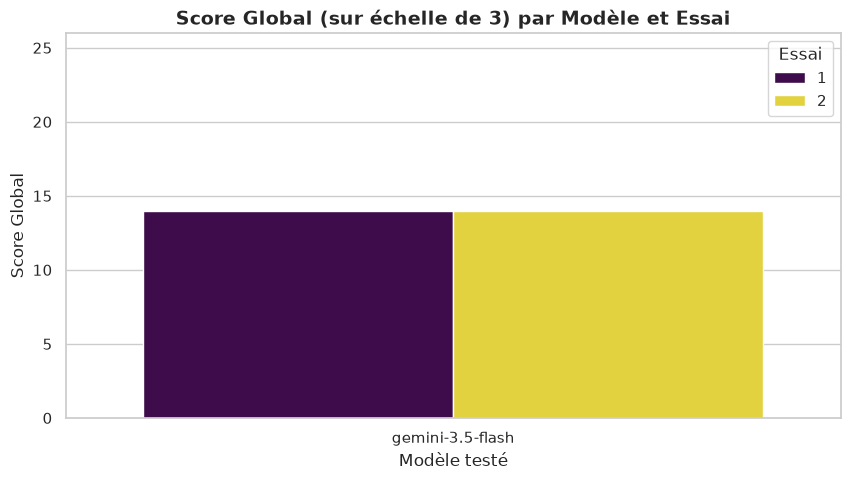

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

# Graphique de comparaison des scores globaux par modèle
ax = sns.barplot(
    data=df,
    x="Modèle",
    y="Score_Global_3",
    hue="Essai",
    palette="viridis"
)

plt.title("Score Global (sur échelle de 3) par Modèle et Essai", fontsize=14, fontweight='bold')
plt.ylabel("Score Global")
plt.xlabel("Modèle testé")
plt.ylim(0, df["Max_Global_3"].max() + 2 if "Max_Global_3" in df.columns else 24)
plt.legend(title="Essai")
plt.show()

In [7]:
def inspecter_analyse(index_ligne=0):
    """Affiche de manière propre et lisible les justifications d'un lift précis."""
    row = df.iloc[index_ligne]
    
    print("=" * 90)
    print(f"🏋️ FICHIER : {row.get('Fichier')} | MODÈLE : {row.get('Modèle')} | ESSAI : {row.get('Essai')}")
    print(f"📊 SCORE GLOBAL : {row.get('Score_Global_3')}/{row.get('Max_Global_3')} | PERSONA : {row.get('Persona')}")
    print(f"💬 JUSTIFICATION PERSONA : {row.get('Persona_Justification')}")
    print("=" * 90)
    
    cols_explanations = [c for c in df.columns if c.endswith("_explanation")]
    for exp_col in cols_explanations:
        base_name = exp_col.replace("_explanation", "")
        note_4 = row.get(f"{base_name}_note_4", "N/A")
        note_3 = row.get(f"{base_name}_note_3", "N/A")
        crit_title = base_name.replace("_", " ").upper()
        
        print(f"\n🔹 {crit_title} (Note /4 : {note_4} | Note /3 : {note_3})")
        print(f"   ↳ {row[exp_col]}")

# Pour inspecter le 1er résultat (index 0) :
inspecter_analyse(0)

🏋️ FICHIER : video.mp4 | MODÈLE : gemini-3.5-flash | ESSAI : 1
📊 SCORE GLOBAL : 14/24 | PERSONA : The Technician
💬 JUSTIFICATION PERSONA : Your lifts display highly consistent mechanics, controlled descents, and excellent spinal neutrality across all repetitions.

🔹 STARTING POSITION (Note /4 : 3 | Note /3 : 2)
   ↳ nan

🔹 SLACK PULL AND LAT ENGAGEMENT (Note /4 : 2 | Note /3 : 1)
   ↳ nan

🔹 LEG DRIVE ACTIVATION (Note /4 : 2 | Note /3 : 1)
   ↳ nan

🔹 HIP HINGE MECHANICS (Note /4 : 3 | Note /3 : 2)
   ↳ nan

🔹 CORE BRACING AND SPINE NEUTRALITY (Note /4 : 3 | Note /3 : 2)
   ↳ nan

🔹 BAR PATH AND PROXIMITY (Note /4 : 3 | Note /3 : 2)
   ↳ nan

🔹 LOCKOUT EXECUTION (Note /4 : 3 | Note /3 : 2)
   ↳ nan

🔹 ECCENTRIC CONTROL AND DESCENT (Note /4 : 3 | Note /3 : 2)
   ↳ nan
